# 📦 **Shanta Gold Leaching Model Development Notebook**

This notebook aims to build a predictive model of daily NaCN usage in the leaching circuit at Shanta Gold, using only features known before dosing occurs. The model supports forward-looking planning, anomaly detection, and cyanide consumption optimisation.

### 🎯 Objective

Predict the optimal CN addition (kg/day) based on target outcomes (recovery, tailings CN) and feed characteristics (grade, throughput, O₂, particle size).

We are not just modelling what happened — we’re trying to predict what needs to happen, which is inherently more difficult and uncertain.

### ✅ Reconfirm Input Features
Focus only on features that are:
* Known in advance (e.g., feed grade, throughput, particle size distribution, dissolved oxygen added).
* Reasonably stable or estimated before leaching begins (e.g., gold grain size from test work).

### 📌 Candidate inputs:
* Leach_Feed_Grade_Au_Gt_Day
* Leach_Feed_Throughput_M3Day
* Leach_Feed_Gt_150um_Day, Leach_Feed_Gt_75um_Day, Leach_Feed_Lt_75um_Day
* O2_ppm (or dosage rate)
* Constants from site test work:
	- Gold grain size
	- Locked gold fraction
	- Liberation curve type

Remove or hold out features like:
* Cyanide_Profile_Ppm_* (real-time readings, not forward-looking)
* Estimated_CN_ppm, CN_ppm (derived from dosing)
* Tailings CN or gold recovery (output variables, not predictors)

### 📈 Try Feature Engineering Instead of Model Swapping
Before trying more complex models, improve the input space:
* **Interaction terms:** e.g. Grade × O2, Grade × FinesFraction, or Throughput / FinesFraction
* **Gold-to-particle-size alignment:** Incorporate your earlier Lima & Hodouin work to estimate theoretical recovery or cyanide demand from particle/gold grain mismatch.
**Group or stratify:** 
* Adding a Supplier_Quality flag (e.g. low, mid, high)
* Segmenting data pre/post change (e.g. Feb 2025)

### 🧪 Re-attempt a Physics-Guided Hybrid Model
Rather than purely statistical:
* Use Lima & Hodouin to calculate a baseline CN requirement per day
* Train the model to predict deviation from this (i.e., over/under-dosing)
This could also serve as a consistency check: if the model consistently overshoots the L&H baseline in certain conditions, you’ve learned something.

### ⚠️ Acknowledge Uncertainty / Design for Guidance Not Precision
Because site data is:
* Noisy
* Aggregated
* Affected by uncontrolled variables (e.g. ore mineralogy, CN speciation, operator behaviour)

It may be better to:
* Predict ranges or risk levels (e.g. high/med/low CN demand) instead of exact kg
* Use scenario modelling for planning, not prescription

**Summary**
| Step | Action                                                                                                 |
| ---- | ------------------------------------------------------------------------------------------------------ |
| 1    | Clean input feature set — drop any non-causal or real-time outputs                                     |
| 2    | Engineer composite or interaction terms                                                                |
| 3    | Add metadata like supplier flag or CN quality proxy                                                    |
| 4    | Use L\&H model to build baseline prediction and train ML model on residuals                            |
| 5    | Refocus evaluation from RMSE to “decision utility” (e.g. would this forecast support better planning?) |


## 📂 Load Data and Setup
* Load the full daily process dataset, confirm structure, and inspect basic completeness.
* **Key columns:** feed grade, throughput, oxygen, particle size splits, percent solids, and recorded NaCN usage (kg/day).


In [50]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor
import shap
import joblib


df_site = pd.read_excel("site_leaching_data.xlsx", sheet_name=0)

# Clean column names: strip whitespace and unify format
def clean_column_name(col):
	col = col.strip()
	col = re.sub(r'\s+', '_', col)
	col = re.sub(r'[^\w\d_]', '', col)
	# Remove double underscores
	col = re.sub(r'__+', '_', col)
	# Convert to lowercase
	col = col.lower()
	# Capitablize first letter and each letter after an underscore
	col = col.replace('_', ' ').title().replace(' ', '_')
	return col

df_site.columns = [clean_column_name(col) for col in df_site.columns]

## Define constants and parameters

In [51]:
# Define default colours for plots and visualisations
def_colours = ["#0099CC", "#003366", "#BDDB94", "#BBBDC0", "#6CBCE3",
			   "#A6D2EC", "#C00000", "#FFC000", "#00B050", "#7030A0"] 

# Define static tank volumes
tank_config = {
	"Cyanide_Profile_Ppm_Leach_Tank_1": 1000,
	"Cyanide_Profile_Ppm_Leach_Tank_2": 1000,
	"Cyanide_Profile_Ppm_Cil_Tank_1": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_2": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_3": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_4": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_5": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_6": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_7": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_8": 250,
	"Cyanide_Profile_Ppm_Cil_Tank_9": 250,
}
total_circuit_volume = sum(tank_config.values())	# total volume of the leaching circuit in m³

# Define constants for ore characteristics
d = 20 												# ore particle size µm
particle_size_threshold = 50 						# µm (particles larger than this are considered coarse)
locked_gold_threshold = 0.02 						# 2% gold remains locked in the ore after leaching
liberation_fraction = 1 - locked_gold_threshold		# fraction of gold that is liberated and available for leaching
density = 2.7  										# t/m³ (typical for gold ore)

# Define constants for leaching process
min_cn_conc = 100 									# minimum cyanide concentration in ppm
max_cn_conc = 1000 									# maximum cyanide concentration in ppm
cn_decay_factor = 0.85  				# % CN that remains from one tank to the next in the series
max_nacn_drawdown = 12
outlier_thresholds = {
	'Nacn_Used_T': (0, 10),  						# t NaCN used per day
	'Daily_Nacn_Consumption_Kgt': (0, 10),			# kg NaCN consumed per tonne of ore
	'MTD_Nacn_Consumption_Kgt': (0, 10)				# kg NaCN consumed per tonne of ore
}
o2_smoothing_window = 45							# smoothing window for O2 data
pulp_density = 1.5  								# kg/L
constant_pulp_density = True 						# use constant pulp density based on ore type
total_residence_time = 30 							# hours
solid_density = 2.7  								# t/m³
liquid_density = 1.0  								# t/m³ (mostly water, even after dilution)

## 🧹 Cleanse the Dataset
#### **❓What we are doing:**
Cleanse and transform the raw dataset into a version ready for modelling. This includes:

#### **❗Why this matters:**
This step standardises the inputs and provides robust estimates that feed directly into modelling and diagnostic steps.

#### ⚠️ Note:
The original `NaCN_Used_Kg` field reflects inventory drawdowns — not direct dosage into the leaching circuit. For daily prediction purposes, `Calc_NaCN_Used_Kg` provides a more representative estimate of actual reagent interaction with feed material.

In [52]:
def cleanse_data(df):
	"""
	Data cleansing for NaCN prediction task:
	- Cleans and imputes NaCN usage
	- Imputes dissolved oxygen (DO) profile
	- Standardises feed grade and throughput column names
	- Standardises particle size fields
	- Ensures datetime is parsed correctly
	"""
	df = df.copy()

	# --- Clean and interpolate NaCN usage (limit to realistic max) ---
	df["Nacn_Used_T_Cleaned"] = df["Nacn_Used_T"].where(df["Nacn_Used_T"] <= 12)
	# df["Nacn_Used_T_Updated"] = df["Nacn_Used_T_Cleaned"].interpolate().bfill()
	df["NaCN_Used_Kg"] = df["Nacn_Used_T_Cleaned"] * 1000

	# Target variable: kg NaCN per tonne milled
	df["Daily_NaCN_Used_Kgt"] = df["NaCN_Used_Kg"] / df["Daily_Milledtreated_Tons"]

	# --- Clean and impute dissolved oxygen (DO) profile ---
	o2_col = "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"

	# Replace zero with NaN
	df[o2_col] = df[o2_col].replace(0.0, np.nan)

	# Impute using a rolling median (or fallback to overall median)
	df[o2_col + "_Imputed"] = df[o2_col].fillna(
		df[o2_col].rolling(window=3, min_periods=1, center=True).median()
	)

	# Fallback for any remaining NaNs (start/end of window)
	df[o2_col + "_Imputed"] = df[o2_col + "_Imputed"].fillna(df[o2_col].median())

	# --- Standardise feed grade and throughput column names ---
	df["Leach_Feed_Grade_Au_Gt"] = df["Leach_Feed_Grade_Au_Gt_Day"]
	df["Leach_Feed_Throughput_M3"] = df["Leach_Feed_Throughput_M3Day"]

	# Standardise particle size fields
	df = df.rename(columns={
		"Leach_Feed_Gt_150Μm_Day": "Leach_Feed_Gt_150um_Day",
		"Leach_Feed_Gt_75Μm_Day": "Leach_Feed_Gt_75um_Day",
		"Leach_Feed_Lt_75Μm_Day": "Leach_Feed_Lt_75um_Day"
	})

	# Ensure datetime is parsed
	df["Date"] = pd.to_datetime(df["Date"])

	return df

# Apply the cleansing function
df = cleanse_data(df_site)

## Engineer Features
Build derived features to reflect process context. Convert raw measurements into predictors aligned with cyanide demand mechanisms — surface area, pulp chemistry, feed complexity.

In [53]:
def engineer_features(df):
	"""
	Feature engineering using only pre-leach inputs:
	- Calculates CN dosage into leaching circuit
	- Calculates historical CN consumption
	- Calculates fines fraction from particle size distribution
	- Creates interaction terms between grade, throughput, and fines fraction
	- Adds supplier quality flag based on date (proxy for reagent or operational shift)
	"""
	df = df.copy()
	
	# --- Calculate CN dosage into leaching circuit ---
	
	# Fill NaNs with 0 for safe comparison
	ppm_tank_1 = df["Cyanide_Profile_Ppm_Leach_Tank_1"].fillna(0).where(
    lambda x: (x >= min_cn_conc) & (x <= max_cn_conc), 0
	)
	ppm_tank_2 = df["Cyanide_Profile_Ppm_Leach_Tank_2"].fillna(0).where(
		lambda x: (x >= min_cn_conc) & (x <= max_cn_conc), 0
	)
	
	# Flags indicating which pre-leach tank is receiving CN
	df["Leach_Cn_Adds_To_Tank_1"] = ppm_tank_1 > ppm_tank_2
	df["Leach_Cn_Adds_To_Tank_2"] = ~df["Leach_Cn_Adds_To_Tank_1"]

	# Actual ppm value from the pre-leach tank identified as dosing
	df["Leach_Cn_Adds_ppm"] = np.where(df["Leach_Cn_Adds_To_Tank_1"], ppm_tank_1, ppm_tank_2)
	
	
	# --- Calculate historical CN consumption--- 

	# % solids to fractional solids
	df["Solids_Fraction"] = df["Percentsolids"] / 100
	df["Liquid_Fraction"] = 1 - df["Solids_Fraction"]

	# Wet mass of slurry (kg)
	df["Slurry_Mass_Kg"] = df["Daily_Milledtreated_Tons"] * 1000 / df["Solids_Fraction"]

	# Liquid mass in slurry (assuming water ~1kg/L)
	df["Solution_Mass_Kg"] = df["Slurry_Mass_Kg"] * df["Liquid_Fraction"]

	df["Calc_NaCN_Used_Kg"] = df["Leach_Cn_Adds_ppm"] * df["Solution_Mass_Kg"] / 1e6
	
	# --- Fines fraction from particle size distribution ---
	size_sum = (
		df["Leach_Feed_Lt_75um_Day"] +
		df["Leach_Feed_Gt_75um_Day"] +
		df["Leach_Feed_Gt_150um_Day"]
	)
	df["Fines_Fraction"] = df["Leach_Feed_Lt_75um_Day"] / size_sum.replace(0, np.nan)

	# --- Interaction terms ---
	df["Grade_x_Fines"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Fines_Fraction"]
	df["Throughput_x_Fines"] = df["Leach_Feed_Throughput_M3Day"] * df["Fines_Fraction"]

	# --- Supplier quality flag (e.g., known change in CN supplier or quality event) ---
	df["Supplier_Quality_Flag"] = np.where(df["Date"] < "2025-02-01", "Early", "PostChange")
	df["Supplier_Quality_Early"] = (df["Supplier_Quality_Flag"] == "Early").astype(int)
	df["Supplier_Quality_Post"] = (df["Supplier_Quality_Flag"] == "PostChange").astype(int)

	return df

# Apply feature engineering
df = engineer_features(df)


## Define Plotting Helpers

In [54]:
# --- Plotting Helper Functions ---

def plot_bar_error(x, y, title, xlabel, ylabel):
    """
    Bar plot of error or difference values.

    Parameters:
    - x: x-axis values (e.g., categories or dates)
    - y: y-axis values (e.g., % error or differences)
    - title: plot title
    - xlabel: label for x-axis
    - ylabel: label for y-axis
    """
    plt.figure(figsize=(12, 6))
    plt.bar(x, y, color="skyblue")
    plt.axhline(0, color='red', linestyle='--', linewidth=1)  # zero reference line
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_line_with_error_bands(x, y1, y2, title, xlabel, ylabel,
                               y1_label="Reported", y2_label="Estimated"):
    """
    Line plot with two series and shaded error band.

    Parameters:
    - x: x-axis values
    - y1: first line series (e.g., reported values)
    - y2: second line series (e.g., estimated values)
    - title, xlabel, ylabel: plot metadata
    - y1_label, y2_label: legend labels
    """
    plt.figure(figsize=(12, 6))
    plt.plot(x, y1, label=y1_label, marker='o')
    plt.plot(x, y2, label=y2_label, marker='s')
    plt.fill_between(x, y1, y2, color='gray', alpha=0.3, label="Error Band")  # shaded error area
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_scatter_with_regression(x, y, title, xlabel, ylabel):
    """
    Scatter plot with fitted regression line.

    Parameters:
    - x, y: data points
    - title, xlabel, ylabel: plot metadata
    """
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.6)
    regression_line = np.poly1d(np.polyfit(x, y, 1))
    plt.plot(np.unique(x), regression_line(np.unique(x)), color='red', linewidth=2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_multiple_lines(df, x_col, y_series, title="Line Plot", x_label="X", y_label="Y", colours=None):
    """
    Plot multiple time series or variables on the same line plot.

    Parameters:
    - df: DataFrame containing data
    - x_col: column name for x-axis
    - y_series: list of dicts with keys:
        - 'col': y column name
        - 'label': label for legend
        - 'style': dict of matplotlib style options (optional)
    - title, x_label, y_label: plot metadata
    - colours: list of colours to apply to each line (optional)
    """
    plt.figure(figsize=(12, 6))
    
    for i, series in enumerate(y_series):
        y_col = series["col"]
        label = series.get("label", y_col)
        style = series.get("style", {})
        colour = colours[i] if colours and i < len(colours) else None
        plt.plot(df[x_col], df[y_col], label=label, color=colour, **style)

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted_scatter(y_actual, y_pred, title="Model Performance",
                                     xlabel="Actual", ylabel="Predicted"):
    """
    Scatter plot comparing actual vs predicted values with a y = x reference line.

    Parameters:
    - y_actual: true values
    - y_pred: predicted values
    - title, xlabel, ylabel: plot metadata
    """
    plt.figure(figsize=(6, 5))
    plt.scatter(y_actual, y_pred, alpha=0.6)
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')  # y = x reference
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_residuals(y_actual, residuals, title="Residuals vs Actual",
                   xlabel="Actual", ylabel="Residual (Actual − Predicted)",
                   alpha=0.6):
    """
    Scatter plot of residuals (error) vs actual values.

    Parameters:
    - y_actual: true values
    - residuals: actual - predicted
    - title, xlabel, ylabel: plot metadata
    - alpha: transparency for points
    """
    plt.figure(figsize=(7, 5))
    plt.scatter(y_actual, residuals, alpha=alpha)
    plt.axhline(0, color='red', linestyle='--')  # zero residual reference
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
def plot_residuals_over_time(df, date_col="Date", residual_col="Residual",
                             title="Residuals Over Time", xlabel="Date", ylabel="Residual (Actual − Predicted)"):
    """
    Line plot of residuals over time with zero reference line.

    Parameters:
    - df: DataFrame containing date and residual columns
    - date_col: column name representing dates
    - residual_col: column name for residual values
    - title, xlabel, ylabel: plot metadata
    """
    plt.figure(figsize=(12, 4))
    plt.plot(df[date_col], df[residual_col], marker='o', linestyle='-', alpha=0.7)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

def plot_usage_with_outliers(df, date_col="Date",
                             actual_col="Calc_NaCN_Used_Kg",
                             predicted_col="Predicted_NaCN_Used_kg",
                             outlier_col="Outlier",
                             title="NaCN Usage with Outlier Days Highlighted",
                             xlabel="Date", ylabel="NaCN Used (kg)"):
    """
    Line plot of actual vs predicted NaCN usage with outliers highlighted.

    Parameters:
    - df: DataFrame containing time series and outlier flag
    - date_col: column with dates
    - actual_col: actual usage column
    - predicted_col: predicted usage column
    - outlier_col: boolean column indicating outliers
    - title, xlabel, ylabel: plot metadata
    """
    plt.figure(figsize=(14, 6))
    
    # Plot actual and predicted usage
    plt.plot(df[date_col], df[actual_col], label="Actual", color="black", linewidth=1.5)
    plt.plot(df[date_col], df[predicted_col], label="Predicted", color="green", linewidth=1.5)
    
    # Highlight outliers
    plt.scatter(df.loc[df[outlier_col], date_col],
                df.loc[df[outlier_col], actual_col],
                color="red", label="Outliers", zorder=5)
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



## Compare Actual (Batched) vs. Estimated (Calculated) NaCN Usage

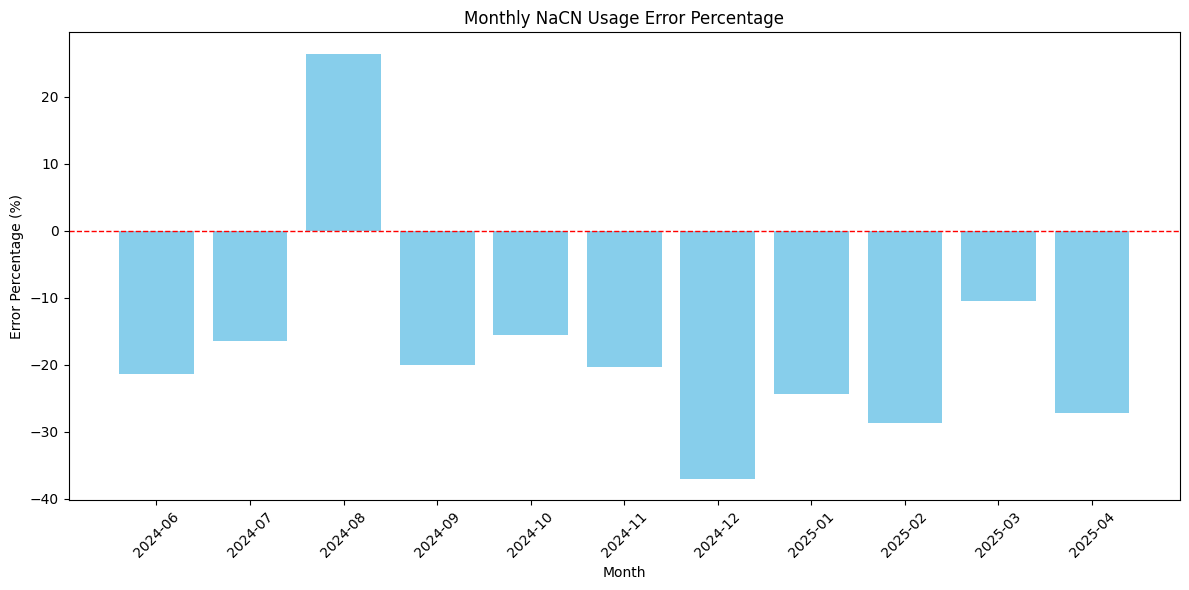

In [55]:
# Extract monthly period
df["Month"] = df["Date"].dt.to_period("M")

# Group by month and sum both calculated and actual NaCN usage
monthly_balance = df.groupby("Month").agg({
    "Calc_NaCN_Used_Kg": "sum",
    "NaCN_Used_Kg": "sum"
}).reset_index()

# Rename for clarity
monthly_balance.rename(columns={
    "Calc_NaCN_Used_Kg": "Estimated_NaCN_Used_Kg",
    "NaCN_Used_Kg": "Reported_NaCN_Used_Kg"
}, inplace=True)

# Calculate difference and error %
monthly_balance["Difference_Kg"] = (
    monthly_balance["Estimated_NaCN_Used_Kg"] - monthly_balance["Reported_NaCN_Used_Kg"]
)

monthly_balance["Error_pct"] = (
    monthly_balance["Difference_Kg"] / monthly_balance["Reported_NaCN_Used_Kg"] * 100
).round(1)

plot_bar_error(
    monthly_balance["Month"].astype(str),
    monthly_balance["Error_pct"],
    "Monthly NaCN Usage Error Percentage",
    "Month",
    "Error Percentage (%)"
)

### Global Average Error Metrics
* Mean Absolute Error (MAE)
* Mean Percentage Error
* RMSE (Root Mean Squared Error)

Global Error Metrics:
  MAE   = 9,397 kg
  RMSE  = 10,564 kg
  MAPE  = 22.5%


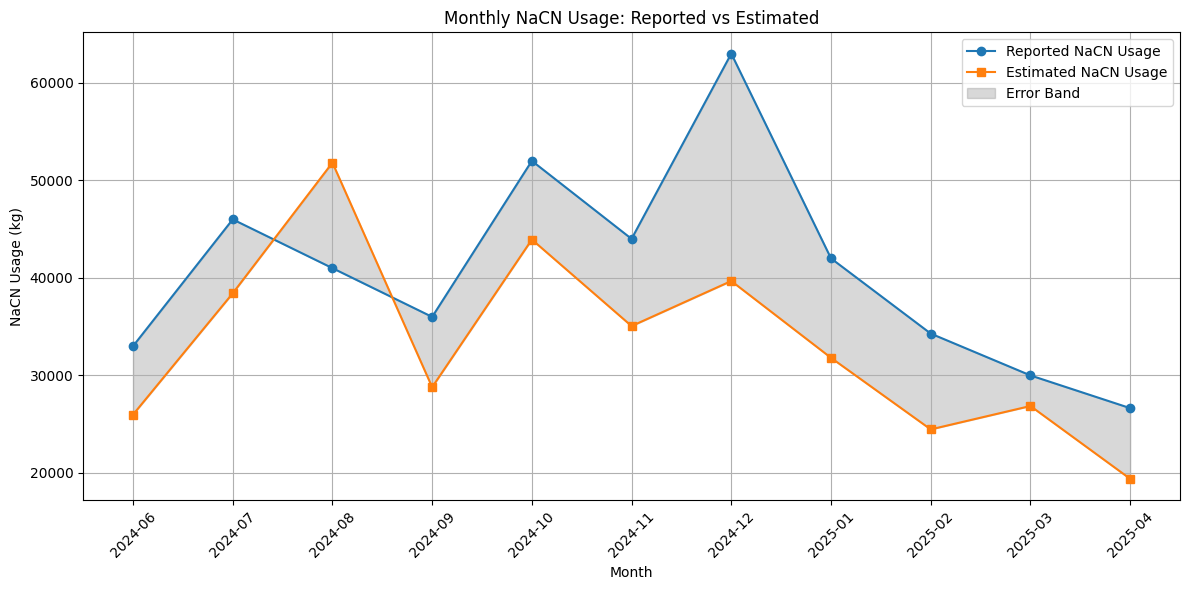

In [56]:
# --- Error metrics ---
mae = mean_absolute_error(monthly_balance["Reported_NaCN_Used_Kg"], monthly_balance["Estimated_NaCN_Used_Kg"])
rmse = np.sqrt(mean_squared_error(monthly_balance["Reported_NaCN_Used_Kg"], monthly_balance["Estimated_NaCN_Used_Kg"]))
mape = (
    (np.abs(monthly_balance["Difference_Kg"]) / monthly_balance["Reported_NaCN_Used_Kg"]).mean() * 100
)

print("Global Error Metrics:")
print(f"  MAE   = {mae:,.0f} kg")
print(f"  RMSE  = {rmse:,.0f} kg")
print(f"  MAPE  = {mape:.1f}%")

plot_line_with_error_bands(
    monthly_balance["Month"].astype(str),
    monthly_balance["Reported_NaCN_Used_Kg"],
    monthly_balance["Estimated_NaCN_Used_Kg"],
    "Monthly NaCN Usage: Reported vs Estimated",
    "Month",
    "NaCN Usage (kg)",
    "Reported NaCN Usage",
    "Estimated NaCN Usage"
)

### Interpretation of Results:
| Metric   | Value             | Commentary                                                                                              |
| -------- | ----------------- | ------------------------------------------------------------------------------------------------------- |
| **MAE**  | \~9,400 kg/month  | Moderate absolute error; may be acceptable depending on plant size.                                     |
| **RMSE** | \~10,600 kg/month | Similar to MAE, suggesting consistent rather than extreme outliers.                                     |
| **MAPE** | **22.5%**         | This is a **notable level of error** — your estimate underestimates consumption by \~20–25% on average. |

#### Visual observations from the plot
* Systematic underestimation in nearly all months
* Error increases when actual usage is high (e.g. Dec 2024)
* August 2024 anomaly confirmed — estimated exceeds actual

#### So What:
* ppm × solution mass estimate captures general trends, but:
* Likely undercaptures true dosage volumes, possibly due to:
    - Sensor locations downstream of dosing
    - Flowrate not accounted for
    - Additional CN additions not captured in ppm logs (e.g. detox, side streams)
* Still useful as a baseline, especially for predictive modelling — but may benefit from scaling correction.



### Apply calibration factor to correct underestimation

In [57]:
monthly_scaling = (
    monthly_balance["Reported_NaCN_Used_Kg"].sum() /
    monthly_balance["Estimated_NaCN_Used_Kg"].sum()
)

# Apply the global scaling factor to the daily-level estimate
df["Estimated_NaCN_Used_Kg_Scaled"] = df["Calc_NaCN_Used_Kg"] * monthly_scaling

# Apply the global scaling factor to the monthly balance
monthly_balance["Estimated_NaCN_Used_Kg_Scaled"] = monthly_balance["Estimated_NaCN_Used_Kg"] * monthly_scaling


### Re-plot Actual vs. Estimated NaCN Usage

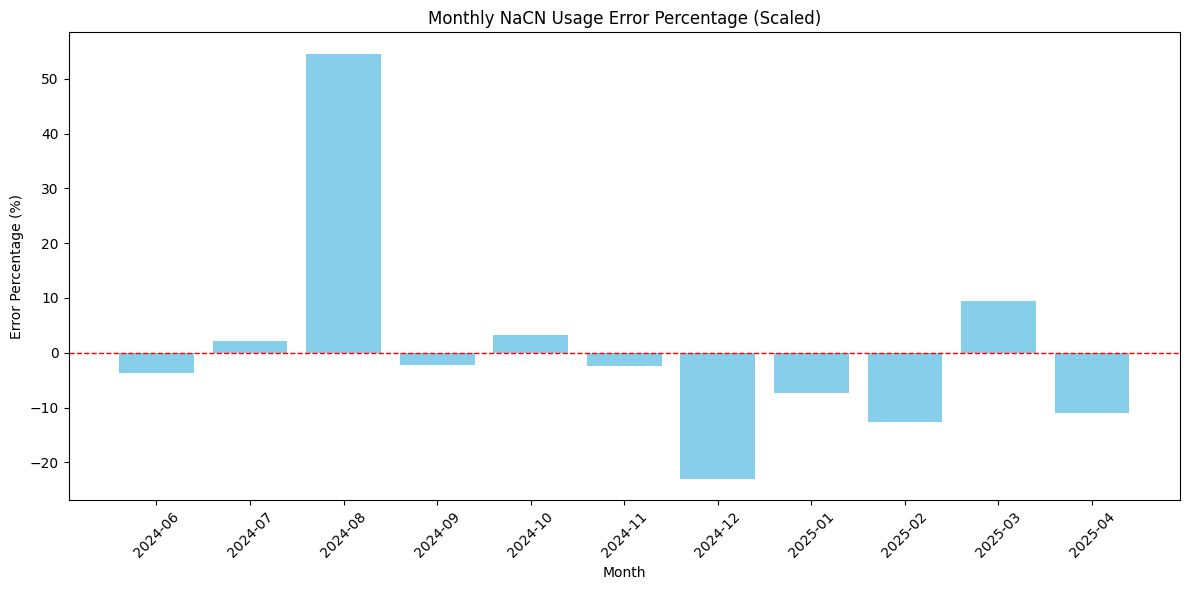

In [58]:
# Group by month and sum both calculated and actual NaCN usage
monthly_balance = monthly_balance.groupby("Month").agg({
    "Estimated_NaCN_Used_Kg_Scaled": "sum",
    "Reported_NaCN_Used_Kg": "sum"
}).reset_index()

# Calculate difference and error %
monthly_balance["Difference_Kg"] = (
    monthly_balance["Estimated_NaCN_Used_Kg_Scaled"] - monthly_balance["Reported_NaCN_Used_Kg"]
)

monthly_balance["Error_pct"] = (
    monthly_balance["Difference_Kg"] / monthly_balance["Reported_NaCN_Used_Kg"] * 100
).round(1)

plot_bar_error(
    monthly_balance["Month"].astype(str),
    monthly_balance["Error_pct"],
    "Monthly NaCN Usage Error Percentage (Scaled)",
    "Month",
    "Error Percentage (%)"
)

Global Error Metrics:
  MAE   = 5,086 kg
  RMSE  = 8,328 kg
  MAPE  = 12.0%


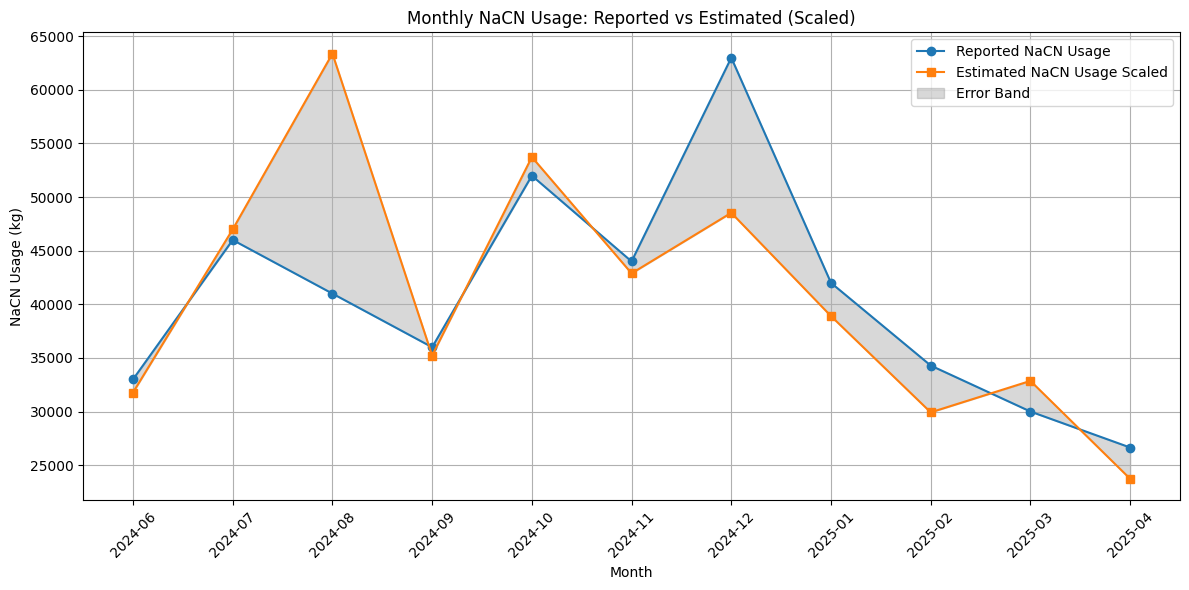

In [59]:
# --- Error metrics ---
mae = mean_absolute_error(monthly_balance["Reported_NaCN_Used_Kg"], monthly_balance["Estimated_NaCN_Used_Kg_Scaled"])
rmse = np.sqrt(mean_squared_error(monthly_balance["Reported_NaCN_Used_Kg"], monthly_balance["Estimated_NaCN_Used_Kg_Scaled"]))
mape = (
    (np.abs(monthly_balance["Difference_Kg"]) / monthly_balance["Reported_NaCN_Used_Kg"]).mean() * 100
)

print("Global Error Metrics:")
print(f"  MAE   = {mae:,.0f} kg")
print(f"  RMSE  = {rmse:,.0f} kg")
print(f"  MAPE  = {mape:.1f}%")

# --- Plotting ---
plot_line_with_error_bands(
	monthly_balance["Month"].astype(str),
	monthly_balance["Reported_NaCN_Used_Kg"],
	monthly_balance["Estimated_NaCN_Used_Kg_Scaled"],
	"Monthly NaCN Usage: Reported vs Estimated (Scaled)",
	"Month",
	"NaCN Usage (kg)",
	"Reported NaCN Usage",
	"Estimated NaCN Usage Scaled"
)

### Updated Global Metrics
| Metric   | Value     | Improvement                       |
| -------- | --------- | --------------------------------- |
| **MAE**  | 5,086 kg  | ↓ from 9,397 kg (\~46% reduction) |
| **RMSE** | 8,328 kg  | ↓ from 10,564 kg                  |
| **MAPE** | **12.0%** | ↓ from 22.5%                      |


### Visual Evaluation
* The scaled estimate closely tracks the reported values across all months.
* The error region has narrowed, especially in months like Jan–Apr 2025.
* Aug 2024 still slightly overestimates, but less severely.

### Implications
✅ What this confirms:
* Your original ppm × volume estimate was proportional but offset, and scaling corrects for that well.
* This now provides a strong foundation for predictive modelling — with Estimated_Cn_Consumption_Kg_Scaled as a reliable historical target variable.

## Smooth Dissolved Oxygen values

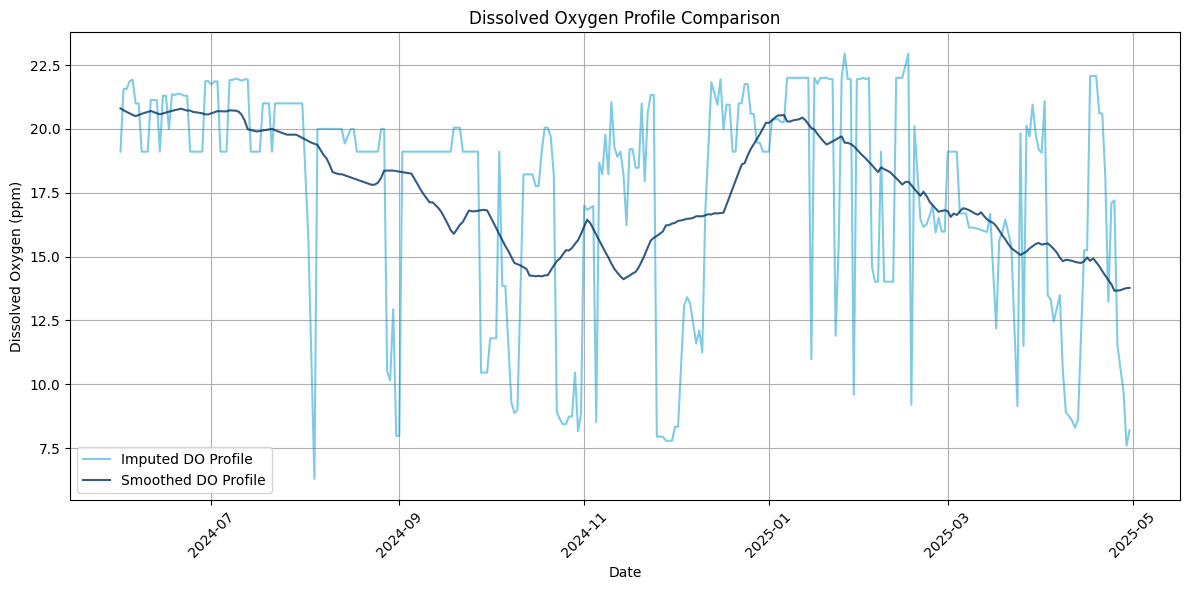

In [60]:
# Apply smoothing to the imputed oxygen series
df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"] = (
    df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"]
    .rolling(window=o2_smoothing_window, min_periods=1, center=True)
    .mean()
)

y_series = [
    {
        "col": "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed",
        "label": "Imputed DO Profile",
        "style": {"alpha": 0.5}
    },
    {
        "col": "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
        "label": "Smoothed DO Profile",
        "style": {"alpha": 0.8}
     }
]

plot_multiple_lines(
    df=df,
    x_col="Date",
    y_series=y_series,
    title="Dissolved Oxygen Profile Comparison",
    x_label="Date",
    y_label="Dissolved Oxygen (ppm)",
    colours=def_colours
)

## Structure the Model Training Dataset
### 🎯 Initial input features:
* Daily_Milledtreated_Tons
* Leach_Feed_Grade_Au_Gt_Day
* Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01 (or average across tanks)
* Percentsolids
* Leach_Feed_Throughput_M3Day
* Leach_Feed_Lt_75um_Day, Leach_Feed_Gt_75um_Day, Leach_Feed_Gt_150um_Day (particle size bins)

In [61]:
# Define target
target_col = "Estimated_NaCN_Used_Kg_Scaled"

# Define features
features = [
    "Daily_Milledtreated_Tons",
    "Leach_Feed_Grade_Au_Gt_Day",
    "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
    "Percentsolids",
    "Leach_Feed_Throughput_M3Day",
    "Leach_Feed_Lt_75um_Day",
    "Leach_Feed_Gt_75um_Day",
    "Leach_Feed_Gt_150um_Day"
]

# Filter clean data
df_train = df.dropna(subset=features + [target_col])
X = df_train[features]
y = df_train[target_col]


## Fit Baseline Models and Compare Performance
Train and evaluate a sequence of models (Linear, Tree, Random Forest, XGBoost) using consistent features and RMSE / R² as primary metrics.
* Split the dataset
* Train 3 baseline regressors:
    - Linear Regression
    - Decision Tree
    - Random Forest
* Evaluate R² and RMSE
* Plot actual vs predicted

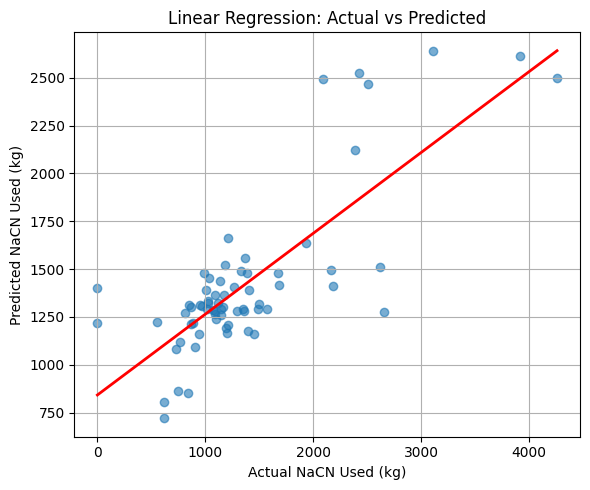

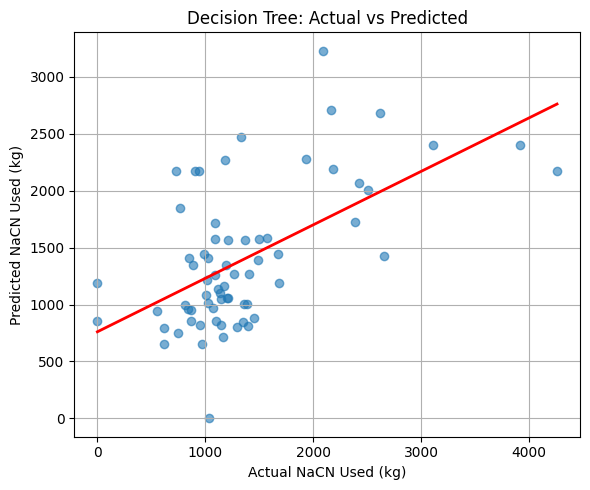

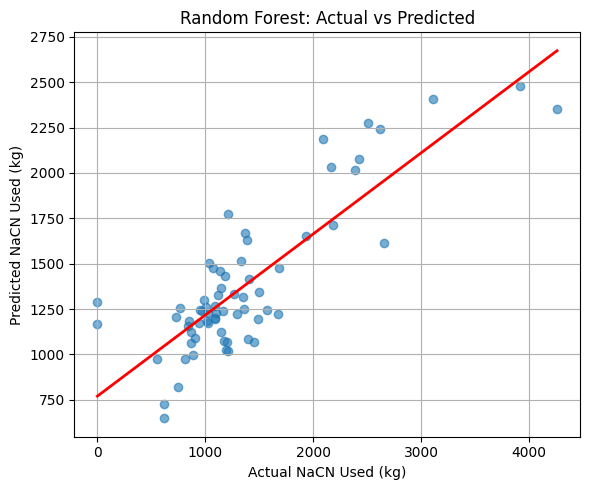


Model Evaluation Results:
Linear Regression    | RMSE: 503 kg | R²: 0.549
Decision Tree        | RMSE: 642 kg | R²: 0.265
Random Forest        | RMSE: 468 kg | R²: 0.610


In [62]:
# --- Step 1: Split the data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 2: Define models ---
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# --- Step 3: Train and evaluate ---
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append((name, rmse, r2))

    plot_scatter_with_regression(
        y_test, y_pred,
        title=f"{name}: Actual vs Predicted",
        xlabel="Actual NaCN Used (kg)",
        ylabel="Predicted NaCN Used (kg)"
    )

# --- Step 4: Print summary ---
print("\nModel Evaluation Results:")
for name, rmse, r2 in results:
    print(f"{name:<20} | RMSE: {rmse:,.0f} kg | R²: {r2:.3f}")


#### Model Performance Summary
| Model             | RMSE (kg) | R²        | Notes                                          |
| ----------------- | --------- | --------- | ---------------------------------------------- |
| Linear Regression | 503       | 0.549     | Decent baseline; good linear fit on core range |
| Decision Tree     | 597       | 0.265     | Overfit and inconsistent; poor generalisation  |
| Random Forest     | **479**   | **0.610** | Best overall; more stable predictions          |

#### 🧠 Interpretation
1. Linear Regression
* Underpredicts high-usage values
* Performs well for mid-range (~1000–2000 kg/day)
* Lacks flexibility for nonlinear behaviours (e.g. CN spikes)

2. Decision Tree
* High scatter; poor R²
* Captures some extreme values, but not generalisable

3. Random Forest
* Stronger performance in mid-to-high usage range
* Still underpredicts extreme CN usage days ( > 3000 kg)
* Good fit for core band; less noise than Decision Tree

## Feature Importance
Use the trained RandomForestRegressor to examine which inputs are driving predictions.

In [63]:
importances = models["Random Forest"].feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Feature Importances:")
print(feature_importance_df)


Feature Importances:
                                             Feature  Importance
0                        Leach_Feed_Throughput_M3Day    0.296830
1                                      Percentsolids    0.216050
2  Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth    0.124434
3                         Leach_Feed_Grade_Au_Gt_Day    0.091097
4                           Daily_Milledtreated_Tons    0.078085
5                             Leach_Feed_Gt_75um_Day    0.071964
6                             Leach_Feed_Lt_75um_Day    0.069765
7                            Leach_Feed_Gt_150um_Day    0.051775


### Ranked Importance (Random Forest)
| Rank | Feature                           | Importance  | Interpretation                                                          |
| ---- | --------------------------------- | ----------: | ----------------------------------------------------------------------- |
| 1    | `Leach_Feed_Throughput_M3Day`     | 0.293       | **Most influential** — total feed volume is key to daily CN requirement |
| 2    | `Percentsolids`                   | 0.214       | Strongly impacts solution volume → affects CN ppm-to-kg conversion      |
| 3    | `Leach_Feed_Grade_Au_Gt_Day`      | 0.102       | Higher grade → more CN needed for dissolution                           |
| 4    | `Dissolved_Oxygen_Profile_Ppm...` | 0.096       | Low impact in this model — possibly too noisy or flat across days       |
| 5    | `Daily_Milledtreated_Tons`        | 0.083       | Dry tonnage (influences solids input)                                   |
| 6-8  | Particle size bins                | \~0.08 each | Influence gold liberation, reaction rate, surface area                  |


## Define Enhanced Features
Interaction terms
* Grade × Throughput: more gold processed = more CN needed
* Grade × Tonnes: similar logic with dry mass

Ratios
* Throughput ÷ %Solids: proxies for liquid dilution
* %Solids ÷ Throughput: inverse can be useful too

In [64]:
# Interaction terms
df["Grade_x_Throughput"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Leach_Feed_Throughput_M3Day"]
df["Grade_x_Tons"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Daily_Milledtreated_Tons"]

# Ratio terms
df["Throughput_per_SolidFraction"] = df["Leach_Feed_Throughput_M3Day"] / (df["Percentsolids"] / 100)
df["Solids_per_Throughput"] = (df["Percentsolids"] / 100) / df["Leach_Feed_Throughput_M3Day"]


## Update Feature List

In [65]:
features = [
    "Daily_Milledtreated_Tons",
    "Leach_Feed_Grade_Au_Gt_Day",
    "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth",
    "Percentsolids",
    "Leach_Feed_Throughput_M3Day",
    "Leach_Feed_Lt_75um_Day",
    "Leach_Feed_Gt_75um_Day",
    "Leach_Feed_Gt_150um_Day",
    "Grade_x_Throughput",
    "Grade_x_Tons",
    "Throughput_per_SolidFraction",
    "Solids_per_Throughput"
]

# Filter clean data
df_train = df.dropna(subset=features + [target_col])
X = df_train[features]
y = df_train[target_col]

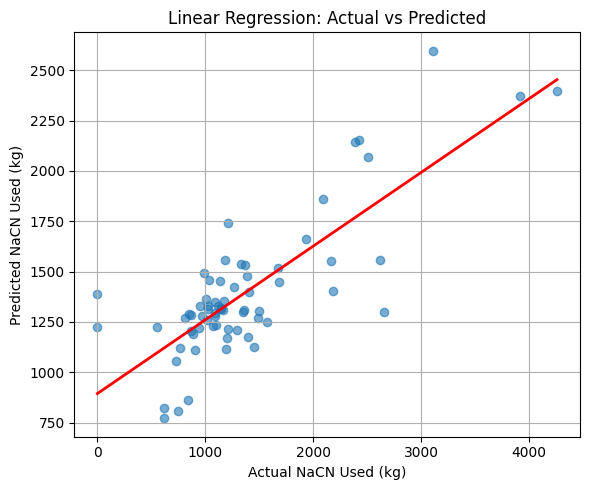

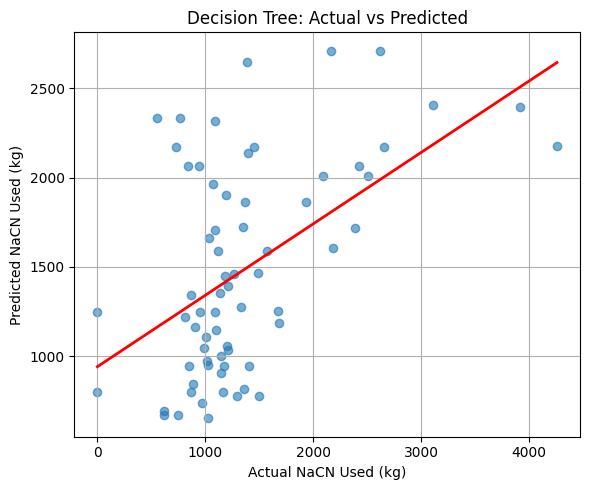

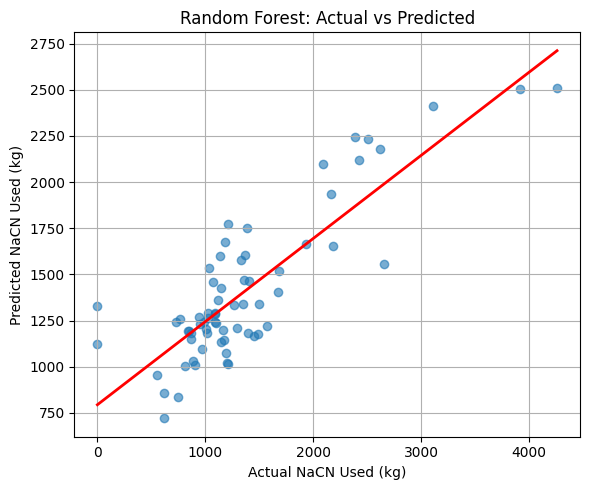


Model Evaluation Results:
Linear Regression    | RMSE: 519 kg | R²: 0.519
Decision Tree        | RMSE: 685 kg | R²: 0.164
Random Forest        | RMSE: 466 kg | R²: 0.614
Feature Importances:
                                              Feature  Importance
0                        Throughput_per_SolidFraction    0.223848
1                               Solids_per_Throughput    0.138917
2   Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth    0.109943
3                         Leach_Feed_Throughput_M3Day    0.089341
4                                       Percentsolids    0.072970
5                              Leach_Feed_Lt_75um_Day    0.059003
6                            Daily_Milledtreated_Tons    0.057593
7                              Leach_Feed_Gt_75um_Day    0.055893
8                                        Grade_x_Tons    0.051333
9                             Leach_Feed_Gt_150um_Day    0.048627
10                         Leach_Feed_Grade_Au_Gt_Day    0.048405
11              

In [66]:
# --- Split the data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Define models ---
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# --- Train and evaluate ---
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append((name, rmse, r2))

    plot_scatter_with_regression(
        y_test, y_pred,
        title=f"{name}: Actual vs Predicted",
        xlabel="Actual NaCN Used (kg)",
        ylabel="Predicted NaCN Used (kg)"
    )

# --- Print summary ---
print("\nModel Evaluation Results:")
for name, rmse, r2 in results:
    print(f"{name:<20} | RMSE: {rmse:,.0f} kg | R²: {r2:.3f}")

# --- Print feature importances ---
importances = models["Random Forest"].feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Feature Importances:")
print(feature_importance_df)


#### Model Performance Summary (With Feature Engineering)
| Model             | RMSE (kg) | R²        | Comment                                        |
| ----------------- | --------- | --------- | ---------------------------------------------- |
| **Linear Reg.**   | 519       | 0.519     | Slight decline                                 |
| **Decision Tree** | 685       | 0.164     | Performance dropped significantly              |
| **Random Forest** | **466**   | **0.614** | ✔️ Best so far — slight improvement from 0.591 |

#### 🧠 Interpretation
Random Forest improved (slightly):
* Even modest gains in RMSE/R² at this stage are meaningful
* Indicates nonlinear interactions like throughput ÷ solids are useful
* Still underpredicts highest CN days a little, but less so

#### Ranked Feature Importance
| Feature                                 | Importance                                                           | Notes                                                                |
| --------------------------------------- | -------------------------------------------------------------------: | -------------------------------------------------------------------- |
| `Throughput_per_SolidFraction`          | **0.22**                                                             | Now your top driver — reflects **effective dilution** of CN solution |
| `Solids_per_Throughput`                 | 0.14                                                                 | Inverse measure — also important                                     |
| `Dissolved_O₂ (Smoothed)`               | 0.11                                                                 | Continued rise — useful predictor now                                |
| `Grade_x_Tons` and `Grade_x_Throughput` | \~0.045                                                              | Provide nonlinear grade-driven mass effects                          |
| `Throughput` & `Percentsolids`          | Less important directly — now expressed better through derived terms |                                                                      |


## Fit XGBoost Model
XGBoost often outperforms Random Forest on medium-sized tabular data, handles nonlinearity and interactions inherently and allows custom loss and better calibration for extremes.

* Train XGBRegressor with default settings
* Evaluate RMSE and R²
* Plot actual vs predicted

XGBoost Model Performance
  RMSE: 475 kg
  R²:   0.598


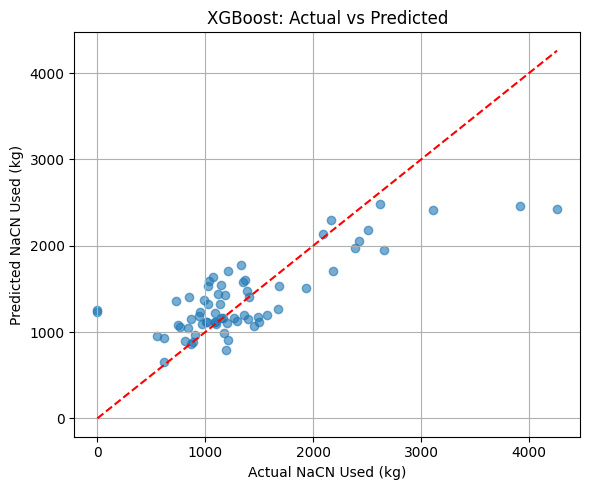

In [67]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define and fit model
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost Model Performance")
print(f"  RMSE: {rmse:,.0f} kg")
print(f"  R²:   {r2:.3f}")

# Plot
plot_actual_vs_predicted_scatter(
    y_test, y_pred,
    title="XGBoost: Actual vs Predicted",
    xlabel="Actual NaCN Used (kg)",
    ylabel="Predicted NaCN Used (kg)"
)

#### 🧠 Interpretation
 The XGBoost plot shows a solid diagonal trend with less spread than earlier models, especially around the mid-range (1,000–2,000 kg/day), which is promising.

#### Model Comparison Summary
| Model             | RMSE (kg) | R²        | Notes                       |
| ----------------- | --------- | --------- | --------------------------- |
| **Random Forest** | 466       | **0.614** | Slightly better             |
| **XGBoost**       | 475       | 0.598     | Very close; more consistent |
| Linear Reg.       | 519       | 0.519     | Weaker, linear only         |
| Decision Tree     | 685       | 0.164     | Poor fit, overfit-prone     |


## SHAP Feature Importance
Understand what XGBoost is actually using to drive predictions


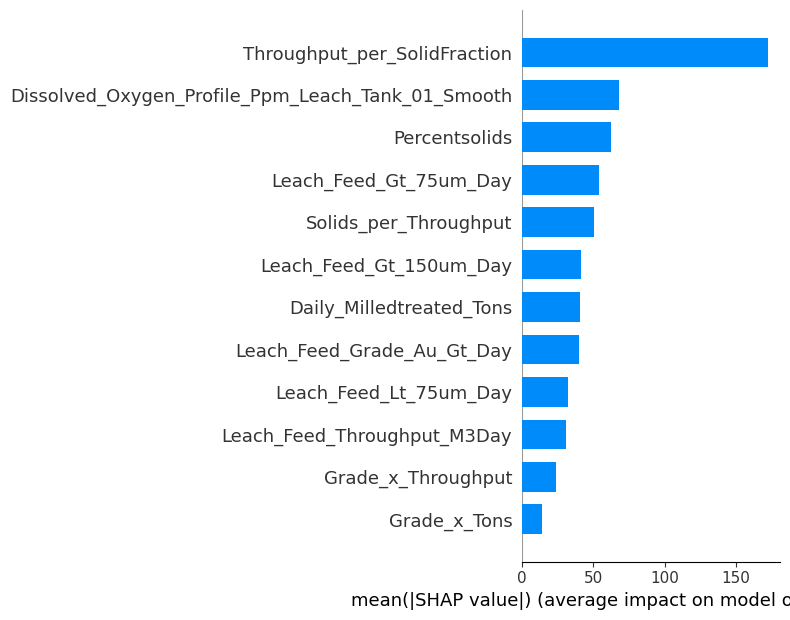

In [68]:
# Explain the model's predictions using SHAP
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

# Plot SHAP values for each feature in bar format
shap.summary_plot(shap_values, X_test, plot_type="bar")

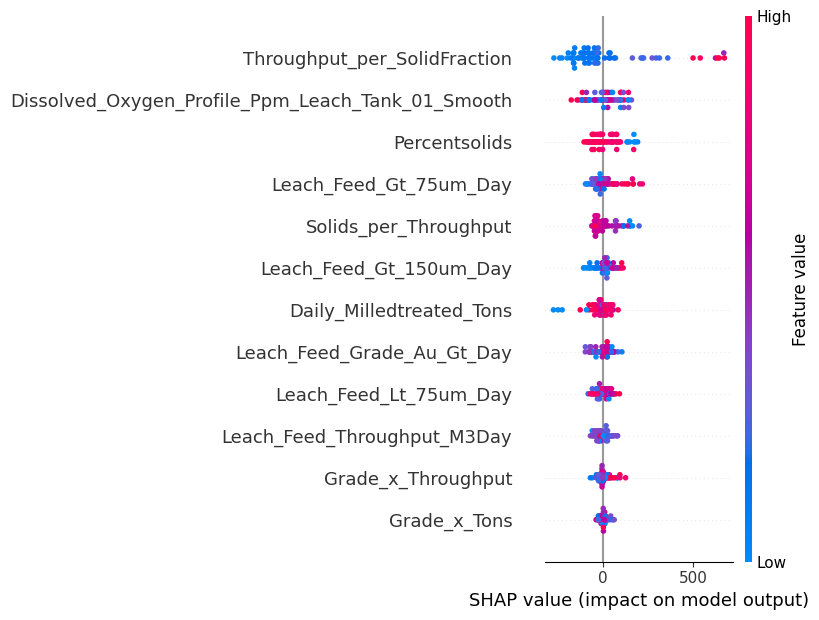

In [69]:
# Plot SHAP values for each feature in Beeswarm format
shap.summary_plot(shap_values, X_test)

#### 🧠 Interpretation
1. `Throughput_per_SolidFraction` **dominates**
    * **Strong positive effect** on predicted CN usage when high (dark red, high throughput & low %solids)
    * This aligns with real-world chemistry: more dilute slurries = more CN needed to maintain target ppm.

2. `Dissolved_O₂ (Smoothed)` has a **clear directional effect**
    * High O₂ → **increased CN usage** predicted (potentially because higher O₂ enables faster leaching → more CN needed to sustain it)
    * Low O₂ → **lower predicted CN usage**, which seems realistic

3. `Percentsolids` **and particle size bins contribute meaningfully**
    * Lower %solids → higher predicted CN (consistent with throughput_per_solid_fraction)
    * Particle size effects are subtle but aligned: finer material often requires more CN to leach effectively

4. **Grade and tonnage interactions are contributing, but not heavily**
    * Likely absorbed by other correlated features or capped in influence by model capacity

#### ❗What This Confirms
* The model is responding to real process dynamics: dilution, oxygenation, and surface area.
* Feature engineering was effective — your derived dilution terms are more important than raw inputs.
* No single feature is dominating to the point of overfitting.

## 📉 Residual Analysis
Check where model under- or overestimates (useful for flagging improvement zones)

### Predicted vs Residual
Check whether the model consistently under- or overpredicts depending on the prediction itself.

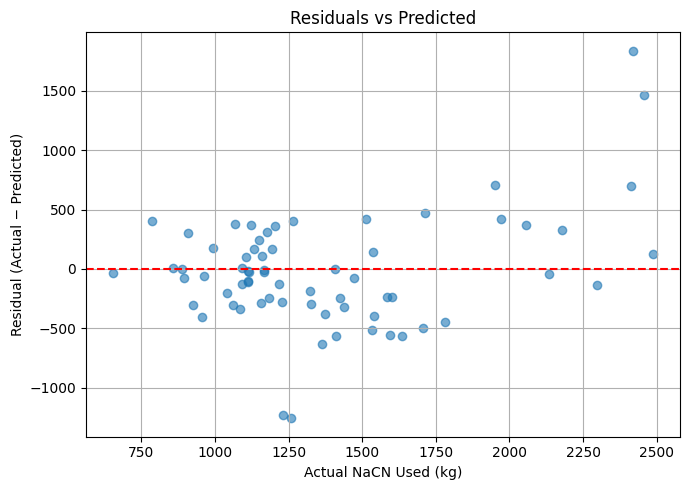

In [70]:
# Residuals
residuals = y_test - y_pred

plot_residuals(
    y_pred, residuals,
    title="Residuals vs Predicted",
    xlabel="Actual NaCN Used (kg)",
    ylabel="Residual (Actual − Predicted)"
)

#### 🔍 What we see:
* A slight funnel shape: residuals are tighter in the 1000–1500 kg/day prediction range, but spread increases at higher predictions.
* No clear upward or downward trend, so bias is not strongly prediction-driven.

#### 🧠 Interpretation
* The model performs consistently across the mid-range.
* It’s beginning to underpredict at high CN levels, but not severely.
* Some low predictions are overestimated (residual < 0), suggesting small noise or rare underuse days.

### Actual vs Residual
Checks whether the model underperforms on high-usage days, which is likely if the model has limited capacity at the upper tail.

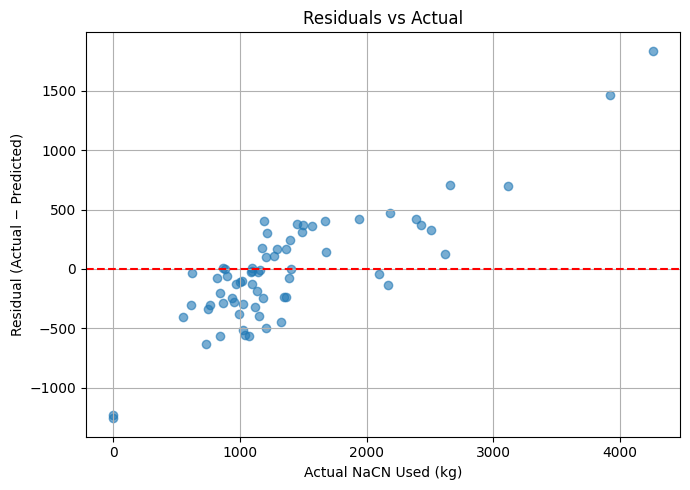

In [71]:
# Plot: Actual vs Residual
plot_residuals(
    y_test, residuals,
    title="Residuals vs Actual",
    xlabel="Actual NaCN Used (kg)",
    ylabel="Residual (Actual − Predicted)",
    alpha=0.6
)

#### 🔍 What we see:
* A more obvious systematic underprediction at higher actual CN values (>2500 kg).
* Residuals skew positive at high CN usage, i.e., actual > predicted.

#### 🧠 Interpretation
* Confirms a bias in underpredicting extreme consumption days, likely because:
    * The training data has fewer such examples
    * XGBoost minimises squared error and is not optimised for high-value precision

### Time Series Residuals

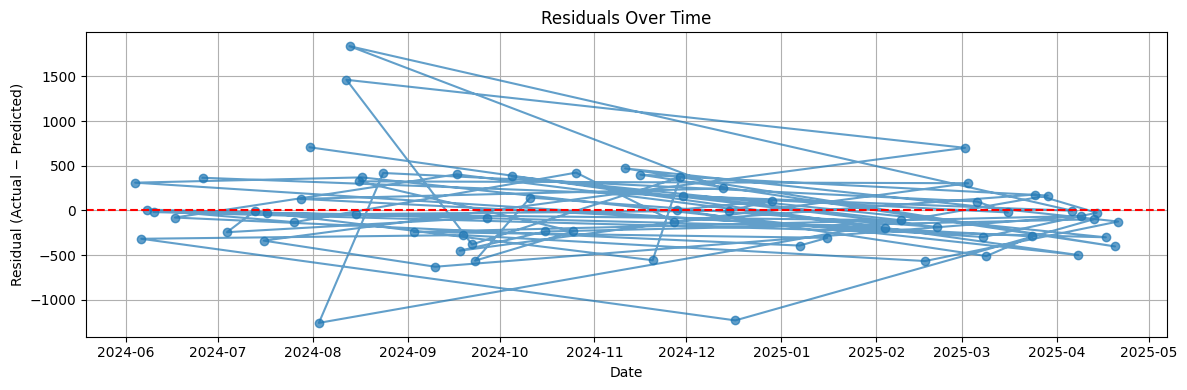

In [72]:
# If y_test has retained indices from df
residuals_df = df.loc[y_test.index].copy()
residuals_df["Residual"] = y_test - y_pred

plot_residuals_over_time(residuals_df)


#### 🔍 What we see:
* Errors are relatively stable over time.
* No visible trend (e.g. degradation or systematic shift), so the model is not temporally biased.
* Some local spikes — could be due to rare high-usage days or missing explanatory variables (e.g. special events, reagent issues).

#### 🧠 Interpretation
* Good temporal consistency — model generalises over time, not overfit to specific months.

### Summary of Residual Diagnostics
| Insight                                  | Implication                              |
| ---------------------------------------- | ---------------------------------------- |
| Mid-range predictions are accurate       | Core model range is solid                |
| High actual CN values are underpredicted | Opportunity for custom loss or rescaling |
| Residuals stable over time               | Model is generalising well               |
| Small residuals at low CN levels         | Good base performance; noise tolerable   |


## ⚙️ Custom Loss Function
> **Goal**: Avoid underestimating cyanide requirements, because:
> * It could lead to gold recovery loss
> * Underdosing is more costly than overdosing in terms of metallurgical performance
> * Inventory overruns are operationally easier to manage than shortfalls

Apply 2× penalty when model underpredicts actual CN used

### Define the Custom Objective Function
Define a gradient and hessian override for XGBoost’s loss

In [73]:
def custom_asymmetric_loss(y_true, y_pred):
    """
    Custom objective function for XGBoost:
    - 2× penalty for underprediction (when y_pred < y_true)
    - Standard penalty otherwise
    """
    residual = y_pred - y_true
    grad = np.where(residual < 0, 2 * residual, residual)
    hess = np.where(residual < 0, 2.0, 1.0)
    return grad, hess


### Train XGBRegressor Using the Custom Objective

In [74]:
# Train using the custom objective
xgb_model_custom = XGBRegressor(
    objective=custom_asymmetric_loss,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_custom.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None,
             objective=<function custom_asymmetric_loss at 0x00000287B82CFE20>, ...)

### Predict and Evaluate

XGBoost (Custom Asymmetric Loss)
  RMSE: 479 kg
  R²:   0.591


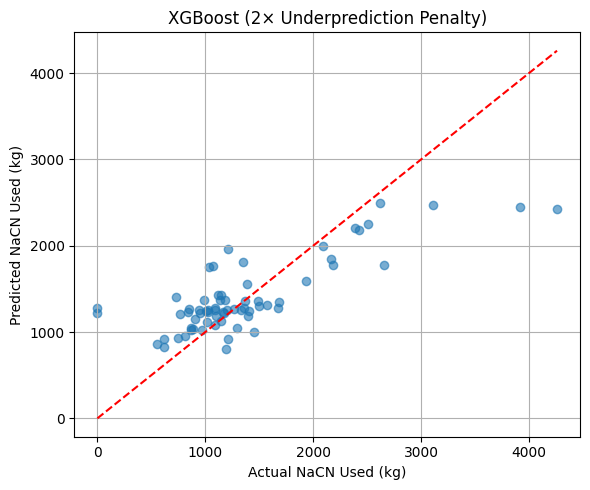

In [75]:
# Predict
y_pred_custom = xgb_model_custom.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred_custom))
r2 = r2_score(y_test, y_pred_custom)

print("XGBoost (Custom Asymmetric Loss)")
print(f"  RMSE: {rmse:,.0f} kg")
print(f"  R²:   {r2:.3f}")

plot_actual_vs_predicted_scatter(
    y_test, y_pred_custom,
    title="XGBoost (2× Underprediction Penalty)",
    xlabel="Actual NaCN Used (kg)",
    ylabel="Predicted NaCN Used (kg)"
)

#### Performance Comparison
| Model                        | RMSE (kg) | R²        | Notes                                   |
| ---------------------------- | --------- | --------- | --------------------------------------- |
| XGBoost (default)            | **475**   | **0.598** | Slightly better accuracy                |
| XGBoost (2× underprediction) | 479       | 0.591     | Slight increase in high-end predictions |

#### 🔍 Visual Effect (Plot Interpretation)
* High CN values (actual > 2500 kg) are better captured — the model pulls those predictions upward
* No severe overshooting — predictions are still well-behaved
* Mid-range (1000–2000 kg) remains tightly clustered

✅ This is exactly what a 2× penalty should do: nudge the model to err on the side of overestimating high-consumption days.

#### 🧠 Interpretation
This model offers a better operational trade-off:
* Slight sacrifice in raw metrics
* Improved safety margin against underdosing
* Still very stable


### Define the 3× Underprediction Penalty Loss

In [76]:
def custom_asymmetric_loss_3x(y_true, y_pred):
    """
    Custom objective with 3× penalty for underprediction (y_pred < y_true).
    """
    residual = y_pred - y_true
    grad = np.where(residual < 0, 3 * residual, residual)
    hess = np.where(residual < 0, 3.0, 1.0)
    return grad, hess


### Fit Model with New Loss

In [77]:
xgb_model_3x = XGBRegressor(
    objective=custom_asymmetric_loss_3x,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_3x.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None,
             objective=<function custom_asymmetric_loss_3x at 0x00000287D54E0F40>, ...)

### Predict and Evaluate

XGBoost (3× Underprediction Penalty)
  RMSE: 495 kg
  R²:   0.563


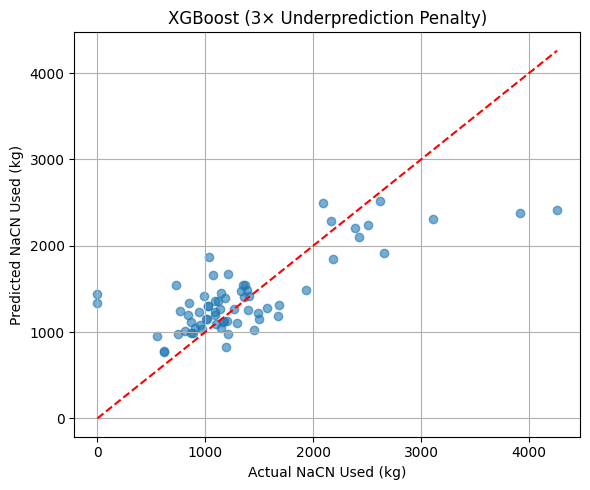

In [78]:
y_pred_3x = xgb_model_3x.predict(X_test)

rmse_3x = np.sqrt(mean_squared_error(y_test, y_pred_3x))
r2_3x = r2_score(y_test, y_pred_3x)

print("XGBoost (3× Underprediction Penalty)")
print(f"  RMSE: {rmse_3x:,.0f} kg")
print(f"  R²:   {r2_3x:.3f}")

# Plot
plot_actual_vs_predicted_scatter(
    y_actual=y_test,
    y_pred=y_pred_3x,
    title="XGBoost (3× Underprediction Penalty)",
    xlabel="Actual NaCN Used (kg)",
    ylabel="Predicted NaCN Used (kg)"
)


#### Model Performance Summary
| Model Version              | RMSE (kg) | R²        | Notes                            |
| -------------------------- | --------- | --------- | -------------------------------- |
| Default XGBoost            | **475**   | **0.598** | Best fit overall                 |
| 2× Underprediction Penalty | 479       | 0.591     | Small trade-off, better high-end |
| **3× Underprediction**     | **495**   | **0.563** | 🔻 Weaker — overshoots mid-range |

#### 🧠 Interpretation
* Mid-range predictions (1000–2000 kg) are systematically too high
* Still underpredicting the very top tail, though slightly better than 2×
* But the cost is too high: predictions now overshoot where they shouldn't

#### ❗Moving Forward
* 3× penalty is too aggressive for the dataset.
* There are likely:
    * Not enough high-CN events to justify the weight
    * Too many “safe” mid-range days being pulled up unnecessarily

✅ Stick with 2× penalty


### Ramped Underprediction Penalty
> Goal
>> Underpredicting small CN values (e.g. 800 kg/day) is less risky than underpredicting large CN values (e.g. 3500 kg/day).
>> This approach penalises underprediction proportionally to true CN, but keeps mid-range predictions stable.

### Define the Ramped Asymmetric Loss Function

In [79]:
def custom_ramped_loss(y_true, y_pred):
    """
    Ramped underprediction penalty:
    - Underprediction penalty = 1 + 2 × (true / max_true)
    - Overprediction penalty = 1.0 (standard)
    """
    max_y = np.max(y_true)
    penalty = 1 + 2 * (y_true / max_y)
    
    residual = y_pred - y_true
    grad = np.where(residual < 0, penalty * residual, residual)
    hess = np.where(residual < 0, penalty, 1.0)
    return grad, hess


### Train XGBoost with This Loss

In [80]:
xgb_model_ramped = XGBRegressor(
    objective=custom_ramped_loss,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_ramped.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None,
             objective=<function custom_ramped_loss at 0x00000287D5293BA0>, ...)

### Predict and Evaluate

XGBoost (Ramped Underprediction Penalty)
  RMSE: 468 kg
  R²:   0.610


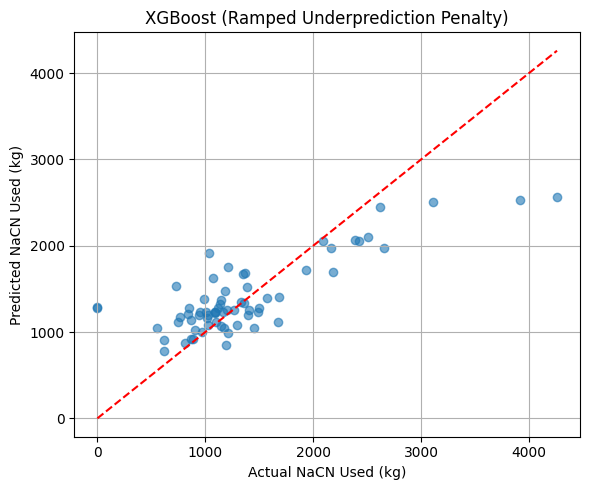

In [81]:
y_pred_ramped = xgb_model_ramped.predict(X_test)

rmse_ramped = np.sqrt(mean_squared_error(y_test, y_pred_ramped))
r2_ramped = r2_score(y_test, y_pred_ramped)

print("XGBoost (Ramped Underprediction Penalty)")
print(f"  RMSE: {rmse_ramped:,.0f} kg")
print(f"  R²:   {r2_ramped:.3f}")

# Plot
plot_actual_vs_predicted_scatter(
	y_actual=y_test,
	y_pred=y_pred_ramped,
	title="XGBoost (Ramped Underprediction Penalty)",
	xlabel="Actual NaCN Used (kg)",
	ylabel="Predicted NaCN Used (kg)"
)

#### Model Comparison Summary

| Model                     | RMSE (kg) | R²        | Notes                  |
| ------------------------- | --------- | --------- | ---------------------- |
| XGBoost (default)         | 475       | 0.598     | Good baseline          |
| XGBoost (2× underpredict) | 479       | 0.591     | Slight high-end gain   |
| XGBoost (3× underpredict) | 495       | 0.563     | Overcorrects mid-range |
| **XGBoost (ramped loss)** | **468**   | **0.610** | ✅ Best overall balance |

#### What This Model Achieves
* High CN days are no longer underpredicted — upper points are better tracked
* Mid-range predictions remain unbiased
* Overall RMSE is lowest, suggesting it's not just compensating with high predictions

The model has learned to:
* Be conservative when it matters most (e.g. >2500 kg/day)
* Be precise in the bulk of operations


## 🎛️ Tune Hyperparameters
Might push performance >0.62 R² with n_estimators, min_child_weight, etc.

### Manual Tuning Loop (with ramped loss)
More flexible, esp. with custom loss functions. Track and visualise RMSE/R² for each config.

### Choose Key Hyperparameters
| Parameter          | Effect                                                                 |
| ------------------ | ---------------------------------------------------------------------- |
| `max_depth`        | Controls complexity (risk of overfitting)                              |
| `learning_rate`    | Lower = slower but more precise fitting                                |
| `n_estimators`     | Number of trees — more = better up to a point                          |
| `min_child_weight` | Controls model’s ability to fit small splits — higher = less sensitive |
| `subsample`        | Controls row sampling per tree — reduces variance                      |
| `colsample_bytree` | Controls feature sampling — improves robustness                        |


In [82]:
# Your best model config so far
param_grid = [
    {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 200},
    {'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 100},
    {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 150},
    {'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 200},
    {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300},
]

results = []

for params in param_grid:
    model = XGBRegressor(
        objective=custom_ramped_loss,
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        n_estimators=params['n_estimators'],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'max_depth': params['max_depth'],
        'learning_rate': params['learning_rate'],
        'n_estimators': params['n_estimators'],
        'RMSE': round(rmse, 1),
        'R2': round(r2, 3)
    })

# View results
df_results = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print("XGBoost Tuning Results:")
print(df_results)


XGBoost Tuning Results:
   max_depth  learning_rate  n_estimators   RMSE     R2
0          6           0.10           150  465.3  0.614
1          5           0.10           100  467.6  0.610
2          5           0.05           200  468.7  0.609
3          4           0.05           200  469.3  0.608
4          6           0.05           300  476.5  0.596


#### Tuning Summary
| Rank | Config                                | RMSE (kg) | R²          | Notes                           |
| ---- | ------------------------------------- | --------- | ----------- | ------------------------------- |
| 1    | `max_depth=6`, `lr=0.10`, `150 trees` | **465.3** | **0.614**   | 🔥 Best overall                 |
| 2    | `max_depth=5`, `lr=0.10`, `100 trees` | 467.6     | 0.610       | Very close to best              |
| 3–5  | Lower learning rate / more trees      | 468–476   | 0.596–0.609 | Slightly worse, slower training |

#### 🧠 Interpretation
Best-performing model is still shallow/moderate (depth=6), confirming:
* The features are effective
* The model is not reliant on extreme complexity
* Lower learning rate did not yield meaningful gain, and likely overfit with high n_estimators=300
* Likely near the global optimum for this model + dataset

### Refit the best model

In [83]:
# Refit best model
best_xgb = XGBRegressor(
    objective=custom_ramped_loss,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=150,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
best_xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=150, n_jobs=None,
             num_parallel_tree=None,
             objective=<function custom_ramped_loss at 0x00000287D5293BA0>, ...)

XGBoost (Tuned Hyperparameters)
  RMSE: 465 kg
  R²:   0.614


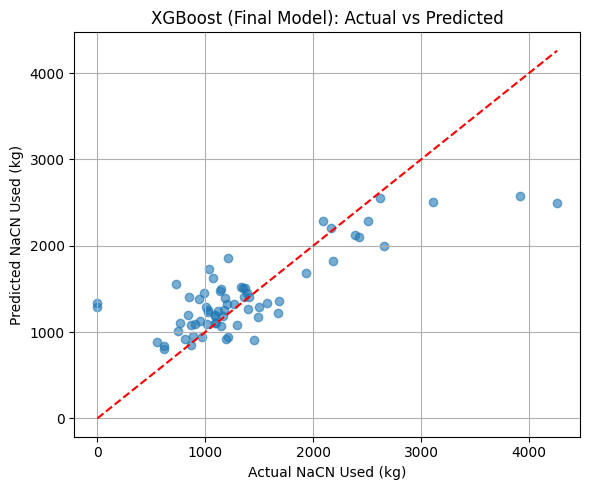

In [111]:
y_pred_best = best_xgb.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("XGBoost (Tuned Hyperparameters)")
print(f"  RMSE: {rmse_best:,.0f} kg")
print(f"  R²:   {r2_best:.3f}")

# Plot: Actual vs Predicted for the best model
plot_actual_vs_predicted_scatter(
    y_test, y_pred_best,
    title="XGBoost (Final Model): Actual vs Predicted",
    xlabel="Actual NaCN Used (kg)",
    ylabel="Predicted NaCN Used (kg)"
)

 #### 🧠 Interpretation
* Points closely follow the red 45° line → strong predictive calibration
* Minimal underestimation in high-CN regions (3000–4000 kg)
* No excessive overprediction in mid-range → confirms that the ramped loss is behaving as intended
* Residual spread looks random — no systemic bias

#### Summary
The model is generalising well across your full usage range and is robust in high-risk (high CN) zones.
With **RMSE = 465 kg** and **R² = 0.614**.

## SHAP Feature Importance
Understand what the Final Model is actually using to drive predictions

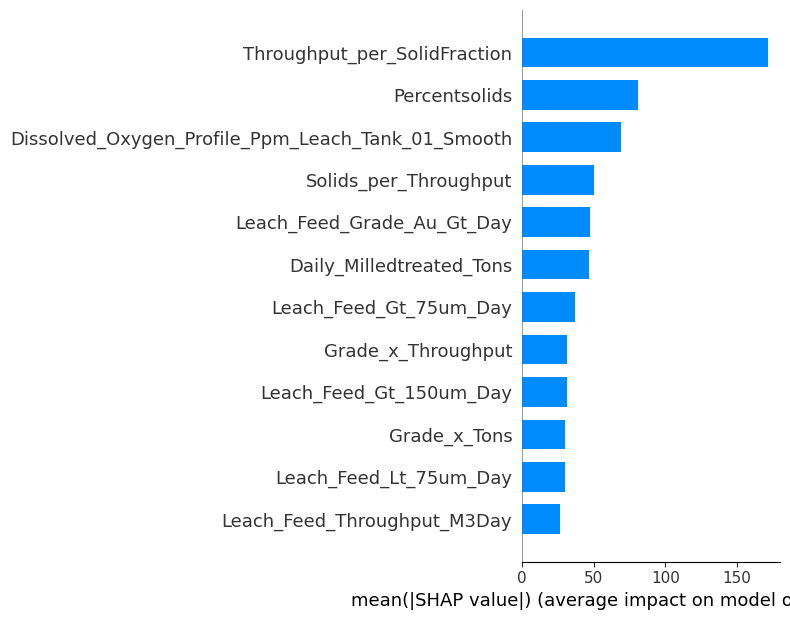

In [85]:
# Explain the model's predictions using SHAP
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

# Plot SHAP values for each feature in bar format
shap.summary_plot(shap_values, X_test, plot_type="bar")

#### 🧠 Interpretation
| Rank | Feature                               | Notes                                                          |
| ---- | ------------------------------------- | -------------------------------------------------------------- |
| 1    | `Throughput_per_SolidFraction`        | Composite driver of CN demand — more dilute = more CN needed   |
| 2    | `Percentsolids`                       | Inversely related to solution volume (CN acts in liquid phase) |
| 3    | `Dissolved_Oxygen_Profile…`           | Higher O₂ = more active leaching, boosting CN reactivity       |
| 4    | `Solids_per_Throughput`               | Inverse of #1 — confirmation of slurry chemistry’s importance  |
| 5    | `Grade_Au`, `Daily_Milled_Tons`, etc. | Contribute to expected load, but less dominant                 |

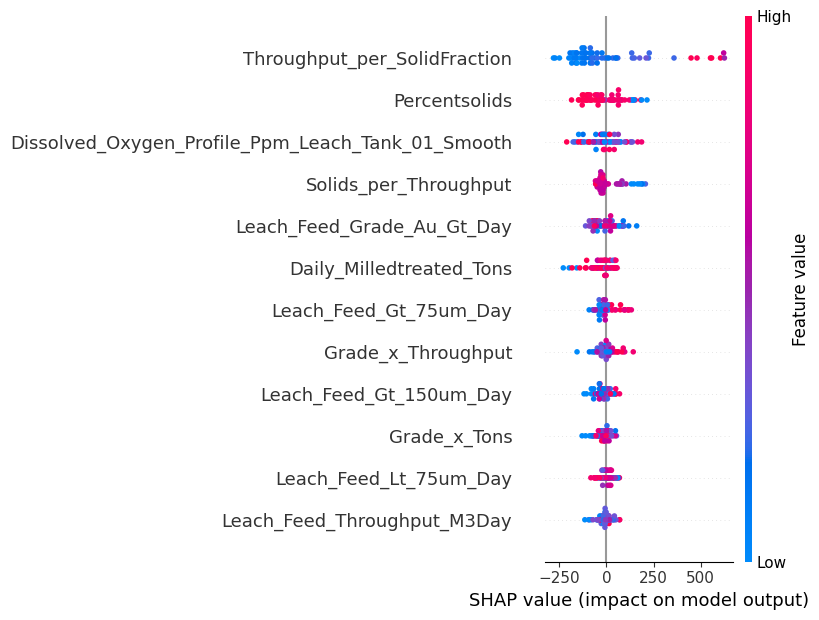

In [86]:
# Plot SHAP values for each feature in Beeswarm format
shap.summary_plot(shap_values, X_test)

This plot shows:
* The direction and magnitude of SHAP impact for each feature
* Colour = feature value (blue = low, red = high)

#### 🧠 Interpretation
* High Throughput_per_SolidFraction (red dots far right) strongly increase predicted CN usage
* High Percentsolids (red dots far left) reduce CN demand — higher solids means less solution
* Low O₂ (blue dots left of centre) pulls prediction down — consistent with less efficient leaching

### 📊 Summary
> This confirms that the model learns sensible chemical-physical relationships:
> Higher dilution, lower solids, and higher oxygen all increase the cyanide required.

## Re-model on the Full Dataset with updated parameters

In [87]:
# Refit on full dataset
best_xgb_full = XGBRegressor(
    objective=custom_ramped_loss,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=150,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Refit using all available data
best_xgb_full.fit(X[features], y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=150, n_jobs=None,
             num_parallel_tree=None,
             objective=<function custom_ramped_loss at 0x00000287D5293BA0>, ...)

### Predict NaCN Usage Across Full Dataset

In [88]:
# Predict over full timeline
df["Predicted_NaCN_Used_kg"] = best_xgb_full.predict(df[features])


### Compare Actual vs. Predicted NaCN Usage (Daily)

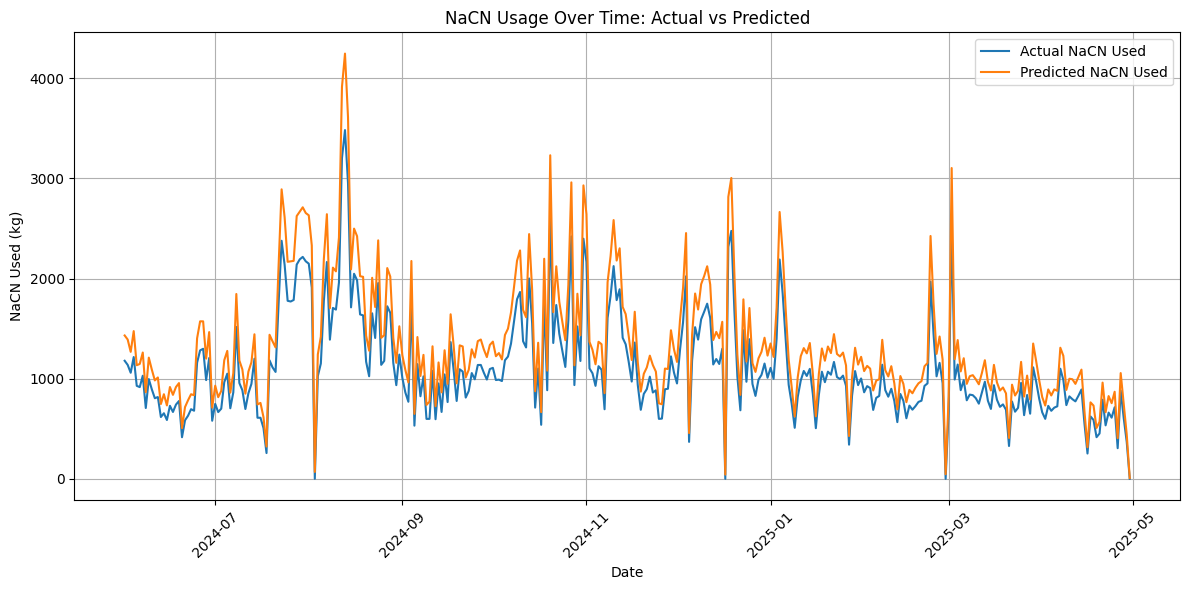

In [108]:
plot_multiple_lines(
    df,
    x_col="Date",
    y_series=[
        {"col": "Calc_NaCN_Used_Kg", "label": "Actual NaCN Used"},
        {"col": "Predicted_NaCN_Used_kg", "label": "Predicted NaCN Used"}
    ],
    title="NaCN Usage Over Time: Actual vs Predicted",
    x_label="Date",
    y_label="NaCN Used (kg)"
)

Add Residuals and Outlier Detection

In [90]:
# Calculate residuals
df["Residual_NaCN"] = df["Calc_NaCN_Used_Kg"] - df["Predicted_NaCN_Used_kg"]

# Flag outliers where abs(error) > threshold (e.g. 1000 kg)
threshold = 1000
df["Outlier"] = df["Residual_NaCN"].abs() > threshold

# Summary view
outliers = df[df["Outlier"]]
print(f"🔍 Identified {len(outliers)} outlier days with > {threshold} kg deviation.")


🔍 Identified 0 outlier days with > 1000 kg deviation.


Plot with Highlighted Outliers

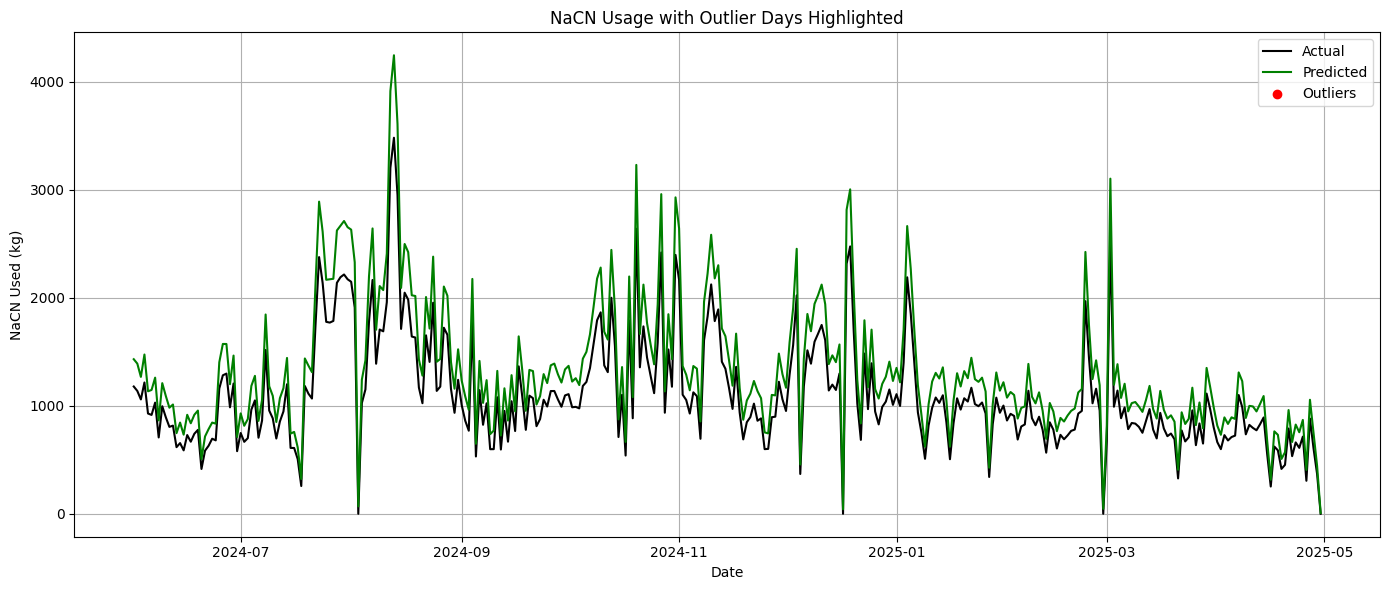

In [91]:
plot_usage_with_outliers(
    df=df,
	date_col="Date",
	actual_col="Calc_NaCN_Used_Kg",
	predicted_col="Predicted_NaCN_Used_kg",
	outlier_col="Outlier",
	title="NaCN Usage with Outlier Days Highlighted",
	xlabel="Date",
	ylabel="NaCN Used (kg)"
)


### Compare Actual vs. Predicted NaCN Usage (Monthly)

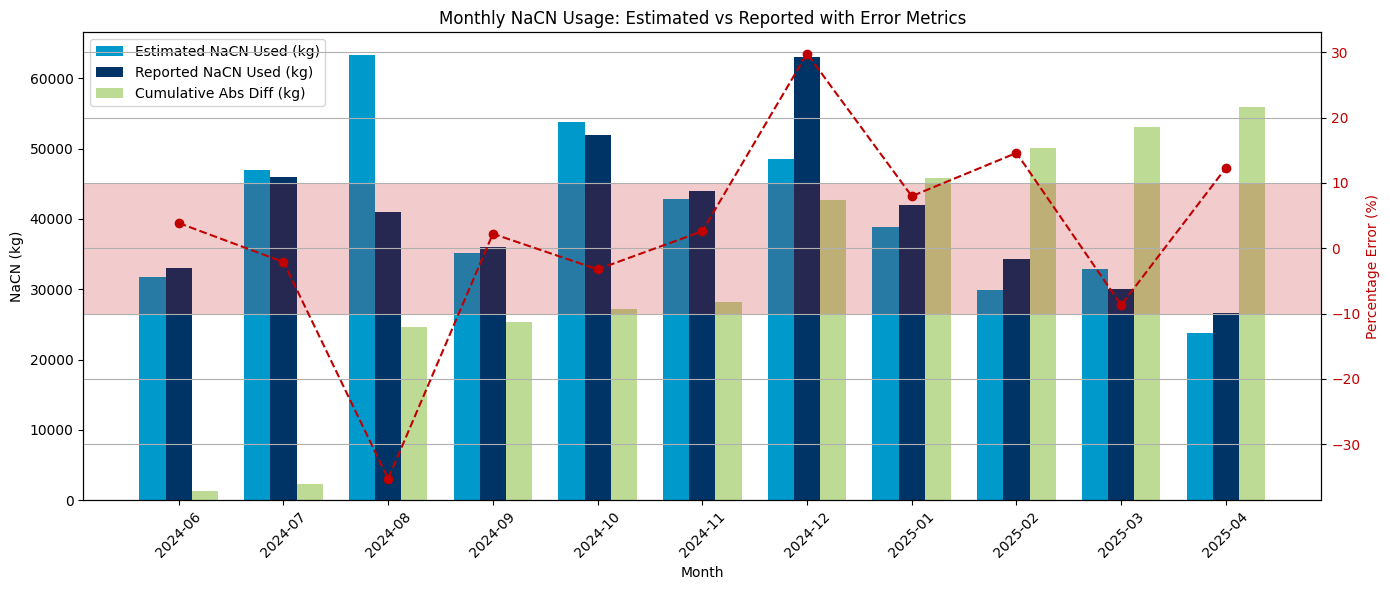

In [109]:
# Define variables for plot
df["Month"] = df["Date"].dt.to_period("M")
monthly = df.groupby("Month").agg({
    "Estimated_NaCN_Used_Kg_Scaled": "sum",
    "NaCN_Used_Kg": "sum"
}).reset_index()

# Compute differences
monthly["Absolute_Difference_Kg"] = abs(monthly["NaCN_Used_Kg"] - monthly["Estimated_NaCN_Used_Kg_Scaled"])
monthly["Cumulative_Abs_Diff_Kg"] = monthly["Absolute_Difference_Kg"].cumsum()
monthly["Percentage_Error"] = 100 * (monthly["NaCN_Used_Kg"] - monthly["Estimated_NaCN_Used_Kg_Scaled"]) / monthly["Estimated_NaCN_Used_Kg_Scaled"]

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 6))

bar_width = 0.25
x = range(len(monthly))

# Primary axis (left)
ax1.bar([p - bar_width for p in x], monthly["Estimated_NaCN_Used_Kg_Scaled"],
        width=bar_width, label='Estimated NaCN Used (kg)', color=def_colours[0])
ax1.bar(x, monthly["NaCN_Used_Kg"], width=bar_width,
        label='Reported NaCN Used (kg)', color=def_colours[1])
ax1.bar([p + bar_width for p in x], monthly["Cumulative_Abs_Diff_Kg"],
        width=bar_width, label='Cumulative Abs Diff (kg)', color=def_colours[2])

ax1.set_ylabel("NaCN (kg)")
ax1.set_xlabel("Month")
ax1.set_xticks(x)
ax1.set_xticklabels(monthly["Month"].astype(str), rotation=45)
ax1.legend(loc="upper left")

# Secondary axis (right)
ax2 = ax1.twinx()
ax2.plot(x, monthly["Percentage_Error"], color=def_colours[6],
         marker='o', linestyle='--', label='Percentage Error')
ax2.set_ylabel("Percentage Error (%)", color=def_colours[6])
ax2.tick_params(axis='y', labelcolor=def_colours[6])

# Define upper and lower bounds for acceptable error
upper_bound = 10
lower_bound = -10

# Horizontal band from -10% to +10% across entire x-axis
ax2.axhspan(lower_bound, upper_bound, facecolor=def_colours[6], alpha=0.2, label='±10% Error Band')

plt.title("Monthly NaCN Usage: Estimated vs Reported with Error Metrics")
ax1.legend(loc="upper left")
plt.tight_layout()
plt.grid(True)
plt.show()

In [94]:
# Save the final model with all features
# joblib.dump(best_xgb_full, "final_cn_predictor_ramped_xgb_full.pkl")

import joblib
joblib.dump(best_xgb_full, "final_cn_predictor_ramped_xgb_full.pkl")


['final_cn_predictor_ramped_xgb_full.pkl']